<a href="https://colab.research.google.com/github/dipaksavitre-don/15assiment/blob/main/assignment28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""Q1. (Loading the Dataset)
Download the Emotions Dataset for NLP from Kaggle (or use the provided
train.txt).
Load the dataset using pandas with separator ; and column names ['text',
'emotions'].
Display the first 10 rows and the shape of the dataset.
Check for missing values using isnull().sum()."""

# hear i cant find the train.txt file ,hence i am using another file instead of it

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

data = pd.read_csv("D:\Datasets\goemotions_dataset\dev.csv")
# displaying the shape of the dataset
print(data.shape)
# displaying the first 10 rows of the dataset
data.head(10)


<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2230/4272031306.py:16: SyntaxWarning: invalid escape sequence '\D'
  data = pd.read_csv("D:\Datasets\goemotions_dataset\dev.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Datasets\\goemotions_dataset\\dev.csv'

In [ ]:
# cheaking for the missing values
data.isnull().sum()

text          0
labels        0
label_ids     0
comment_id    0
dtype: int64

After observing the output there is no missing values in out dataset

In [ ]:
"""Q2. (Exploring Target Labels)
Find and print all unique emotion labels present in the dataset.
Use LabelEncoder to convert the emotion labels into numeric values.
Create a dictionary mapping original emotion names to their encoded numbers
and display it.
Add the encoded labels as a new column in the DataFrame."""

# printing all unique emotion label present in the dataset
data['labels'].unique()

<ArrowStringArray>
[                                 'neutral',
                         'approval,neutral',
                                  'sadness',
                                 'optimism',
                                'gratitude',
                                    'anger',
                              'disapproval',
                                     'love',
                'embarrassment,realization',
                                    'grief',
 ...
                    'curiosity,realization',
                             'love,neutral',
                              'caring,love',
                          'anger,curiosity',
                      'excitement,optimism',
            'caring,disappointment,remorse',
                   'approval,embarrassment',
       'admiration,approval,disappointment',
 'admiration,excitement,gratitude,surprise',
               'admiration,joy,realization']
Length: 296, dtype: str

In [ ]:
data = data.drop('label_ids',axis=1)
data = data.drop('comment_id',axis=1)

# converting the emotion labels into numeric values

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
original_emotions = data['labels'].unique()
data['labels'] = le.fit_transform(data['labels'])
encoded_emotions = data['labels'].unique()
conversion_dict = {}
for i,j in zip(original_emotions,encoded_emotions):
    conversion_dict[i] = j

conversion_dict

{'neutral': np.int64(278),
 'approval,neutral': np.int64(127),
 'sadness': np.int64(293),
 'optimism': np.int64(279),
 'gratitude': np.int64(244),
 'anger': np.int64(66),
 'disapproval': np.int64(196),
 'love': np.int64(270),
 'embarrassment,realization': np.int64(220),
 'grief': np.int64(257),
 'amusement,annoyance,sadness': np.int64(45),
 'anger,annoyance': np.int64(67),
 'annoyance,disapproval': np.int64(97),
 'disappointment': np.int64(186),
 'admiration': np.int64(0),
 'caring,neutral': np.int64(147),
 'curiosity,remorse': np.int64(175),
 'annoyance': np.int64(86),
 'admiration,gratitude': np.int64(28),
 'joy': np.int64(262),
 'fear': np.int64(236),
 'remorse': np.int64(291),
 'amusement': np.int64(41),
 'curiosity': np.int64(162),
 'annoyance,approval': np.int64(87),
 'desire': np.int64(178),
 'approval': np.int64(107),
 'excitement': np.int64(224),
 'amusement,confusion,curiosity,remorse': np.int64(51),
 'confusion': np.int64(153),
 'realization': np.int64(285),
 'admiration,joy

In [ ]:
txt_copy1 = data['text']
text_copy2 = data['text']

In [ ]:
"""Q3. (Lowercasing)
Convert the entire text column to lowercase.
Show 5 sample texts before and after lowercasing.
Write a short note on why lowercasing is important in NLP."""

# 5 sample of text before lowring
data['text'].head(5)

0    Is this in New Orleans?? I really feel like th...
1    You know the answer man, you are programmed to...
2                 I've never been this sad in my life!
3    The economy is heavily controlled and subsidiz...
4    He could have easily taken a real camera from ...
Name: text, dtype: str

In [ ]:
# converting the entire text column to lowercase

data['text'] = data['text'].str.lower()
# 5 samples of text columns after lowring
data['text'].head(5)

0    is this in new orleans?? i really feel like th...
1    you know the answer man, you are programmed to...
2                 i've never been this sad in my life!
3    the economy is heavily controlled and subsidiz...
4    he could have easily taken a real camera from ...
Name: text, dtype: str

In the NLP the upper case and lowercase letters and uppercase letters are treated different i means that if same statement is written in capital letters it should be treated differently that the same in small letters which leads to bad performance of the model and can make model unefficient.


In [ ]:
"""Q4. (Removing Punctuation)
Write a function to remove all punctuation marks from the text.
Apply the function to the text column.
Display 5 examples before and after punctuation removal."""

import string

def remove(text):
    return text.translate(str.maketrans("","",string.punctuation))
# before removing the punctuation
data['text'].head()



0    is this in new orleans?? i really feel like th...
1    you know the answer man, you are programmed to...
2                 i've never been this sad in my life!
3    the economy is heavily controlled and subsidiz...
4    he could have easily taken a real camera from ...
Name: text, dtype: str

In [ ]:
# after removing the punctuation
data['text'] = data['text'].apply(remove)
data['text'].head()

0    is this in new orleans i really feel like this...
1    you know the answer man you are programmed to ...
2                   ive never been this sad in my life
3    the economy is heavily controlled and subsidiz...
4    he could have easily taken a real camera from ...
Name: text, dtype: str

In [ ]:
"""Q5. (Removing Numbers)
Write a function that removes all digits from the text.
Apply it to the cleaned text column.
Show before and after examples."""

# text columns before removing the numbers
data['text'].sample(10)

4889    just having a discussion and giving my opinion...
4790    i will lose my shit on you if you eat in my ca...
2192    the opposite of depression isnt happiness its ...
865     they are dangerous af i had a student faceplan...
3307    rec and red just need to die as teams fucking ...
5196    this is great can anyone make a request with y...
2196    that could have gone extremely badly for all i...
3893    that is so absolutely accurate i couldn’t say ...
4167          i think voit hits 30 so it’s not impossible
1203    lol you could have saved even more time by not...
Name: text, dtype: str

In [ ]:
# text column after removing the numbers
import re
def remove_num(txt):
    return re.sub(r'\d+','',txt)

data['text'] = data['text'].apply(remove_num)

data['text'].sample(10)


3942                     i will downvoted u into oblivion
2851                                  extremely relatable
321        i cant believe the guy is still hanging around
1797    this is one of the coolest things i’ve seen on...
3455                                      you go home now
274        man’s a dreamboat an absolute moisture factory
4979    ugh hate when people talk to me when im fishin...
1997    it’s a bit much her outfit looks basic to me 🤷...
3301                       get out of here with this dude
336     thanks so much for sharing i really appreciate...
Name: text, dtype: str

In [ ]:
"""Q6. (Removing Emojis & Special Characters)
Write a function that keeps only ASCII characters (to remove emojis and special
symbols).
Apply the function to the text column.
Display a few examples of the cleaned text."""

def remove_special(txt):
    return txt.encode('ascii','ignore').decode('ascii')

data['text'] = data['text'].apply(remove_special)
data['text'].sample(10)

285                               i was expecting a kitty
1358    it seems like thats what a lot of people are e...
775     interest rates seem crazy low it doesnt seem w...
5122    thanks for the kind words but some things are ...
4074          mammatus clouds somewhat unusual for sydney
4637    its not because you killed the chicken kill an...
4481    name really about to get a trip dub against us...
231     why its bad for a union rep to be siding with ...
699     does anybody else see strong parallels between...
314     its shit it doesnt let you see schedule inform...
Name: text, dtype: str

In [ ]:
"""Q7. (Removing Stopwords)
Download the necessary NLTK resources (punkt and stopwords).
Load English stopwords.
Write a function to remove stopwords from the text.
Apply the function and show 5 cleaned text samples."""

import nltk

# Download necessary resources
nltk.download('punkt')
nltk.download('stopwords')



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\prita\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\prita\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from nltk.corpus import stopwords
stw = set(stopwords.words('english'))

def remove_stopwords(txt):
    filtered = []
    words = txt.split()

    for i in words:
        if i not in stw:
            filtered.append(f"{i} ")
    return "".join(filtered)

data['text'] = data['text'].apply(remove_stopwords)
data['text'].sample(5)

5006                        id prefer happy little trees 
2170    listened way executed way makes us pay x payin...
2805       never thought bloody obvious pointed good tip 
5307                           really get breaks checked 
2726                                 great thanks advice 
Name: text, dtype: str

In [ ]:
"""Q8. (Complete Text Cleaning Pipeline)
Combine all the cleaning steps from Q3 to Q7 into a single cleaning function.
Apply the complete pipeline on the original text column.
Create a new column called cleaned_text.
Display the original text and cleaned text side by side for 10 samples."""

def clean(txt):
    # lowring the alphabets
    cleaned = txt.str.lower()
    # removing the puncuation
    cleaned = cleaned.apply(lambda txt:txt.translate(str.maketrans("","",string.punctuation)))
    # removing the numbers
    cleaned = cleaned.apply(lambda txt:re.sub(r'\d+','',txt))
    # removing the emogies
    cleaned = cleaned.apply(lambda txt:txt.encode('ascii','ignore').decode('ascii'))
    # removing the stopwords
    words = set(stopwords.words('english'))
    def remove_emoji(txt):
        filtered = []
        statement = txt.split()

        for i in statement:
            if i not in words:
                filtered.append(f"{i} ")

        return "".join(filtered)

    cleaned = cleaned.apply(remove_emoji)

    return cleaned



In [ ]:
# original text column
text_copy2.head(10)

0    Is this in New Orleans?? I really feel like th...
1    You know the answer man, you are programmed to...
2                 I've never been this sad in my life!
3    The economy is heavily controlled and subsidiz...
4    He could have easily taken a real camera from ...
5    Thank you for your vote of confidence, but we ...
6    Wah Mum other people call me on my bullshit an...
7                                         There it is!
8    At least now [NAME] has more time to gain his ...
9    Good. We don't want more thrash liberal offspr...
Name: text, dtype: str

In [ ]:
clened_text = clean(text_copy2)
clened_text.head(10)

0            new orleans really feel like new orleans 
1    know answer man programmed capture codes send ...
2                                  ive never sad life 
3    economy heavily controlled subsidized governme...
4    could easily taken real camera legitimate sour...
5    thank vote confidence statistically cant get w...
6    wah mum people call bullshit cant ban go side ...
7                                                     
8                     least name time gain confidence 
9       good dont want thrash liberal offspring world 
Name: text, dtype: str

In [ ]:
# side by side comparison
for i,j in zip(text_copy2.head(10),clened_text.head(10)):
    print(f"{i}    ||     {j}")

Is this in New Orleans?? I really feel like this is New Orleans.    ||     new orleans really feel like new orleans 
You know the answer man, you are programmed to capture those codes they send you, don’t avoid them!    ||     know answer man programmed capture codes send dont avoid 
I've never been this sad in my life!    ||     ive never sad life 
The economy is heavily controlled and subsidized by the government. In any case, I was poking at the lack of nuance in US politics today    ||     economy heavily controlled subsidized government case poking lack nuance us politics today 
He could have easily taken a real camera from a legitimate source and change the price in Word/Photoshop and then print it out.    ||     could easily taken real camera legitimate source change price wordphotoshop print 
Thank you for your vote of confidence, but we statistically can't get to 10 wins.    ||     thank vote confidence statistically cant get wins 
Wah Mum other people call me on my bullshit a

Text(0, 0.5, 'count of the words')

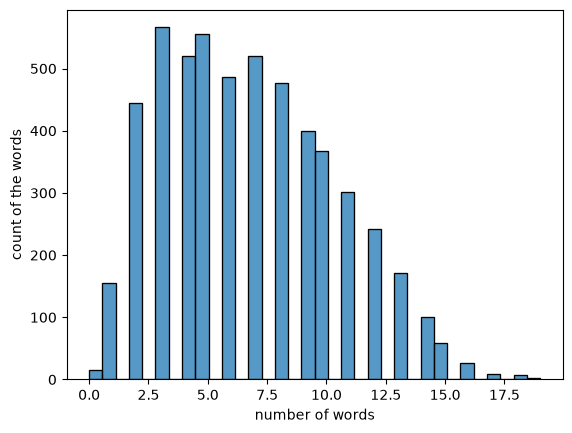

In [ ]:
"""Q9. (Text Length Analysis)
After cleaning:
Calculate the number of words in each cleaned text.
Plot a histogram of text lengths.
Print the average, minimum, and maximum text length.
Write observations about the cleaned data."""

num_words = []

for i in clened_text:
    num_words.append(len(i.split()))

# ploting the histogram
sb.histplot(data=data,x=num_words)
plt.xlabel("number of words")
plt.ylabel("count of the words")

In [ ]:
num_words = pd.DataFrame(num_words)
print(f"Average:{num_words.mean()}")
print(f"minimum:{num_words.min()}")
print(f"maximum:{num_words.max()}")


Average:0    6.771102
dtype: float64
minimum:0    0
dtype: int64
maximum:0    19
dtype: int64


by observing the output of the cleaned data number of words in it , there are only an averate 7 imformative words in their statement describing the situation rest is only the stopwords , the minimum words 0 show that the people even dont have the idea of what the really feeling . the maximum words 19 which have very low intensity on the plot shows that only few people are able to descibe their situation about what the really feeling